In [1]:
import os
import numpy as np
from PIL import Image, ImageOps
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = ConvBlock(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        conv_out = self.conv(x)
        pooled = self.pool(conv_out)
        return conv_out, pooled

class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.upconv = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.upconv(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [4]:
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = Encoder(3, 64)
        self.enc2 = Encoder(64, 128)
        self.enc3 = Encoder(128, 256)
        self.enc4 = Encoder(256, 512)

        self.bottleneck = ConvBlock(512, 1024)

        self.dec1 = Decoder(1024, 512)
        self.dec2 = Decoder(512, 256)
        self.dec3 = Decoder(256, 128)
        self.dec4 = Decoder(128, 64)

        self.final_conv = nn.Conv2d(64, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        s1, p1 = self.enc1(x)
        s2, p2 = self.enc2(p1)
        s3, p3 = self.enc3(p2)
        s4, p4 = self.enc4(p3)

        b = self.bottleneck(p4)

        d1 = self.dec1(b, s4)
        d2 = self.dec2(d1, s3)
        d3 = self.dec3(d2, s2)
        d4 = self.dec4(d3, s1)

        out = self.final_conv(d4)
        return self.sigmoid(out)

In [5]:
class SegmentationDataset(Dataset):
    def __init__(self, folder_path, file_list, img_size=(128, 128), transform=None):
        self.folder_path = folder_path
        self.img_size = img_size
        self.transform = transform
        self.image_files = file_list 

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_file = self.image_files[idx]
        mask_file = img_file.replace(".jpeg", "_m.jpeg")

        img_path = os.path.join(self.folder_path, img_file)
        mask_path = os.path.join(self.folder_path, mask_file)

        image = Image.open(img_path).convert("RGB").resize(self.img_size)
        mask = Image.open(mask_path).convert("L").resize(self.img_size)

        image = np.array(image) / 255.0
        mask = np.array(mask) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        if self.transform:
            image = self.transform(image)
            mask = torch.from_numpy(mask).unsqueeze(0)
        else:
            image = torch.from_numpy(image).permute(2,0,1).float()
            mask = torch.from_numpy(mask).unsqueeze(0)

        return image, mask

In [6]:
def dice_coefficient(preds, targets, smooth=1e-6):
    preds = preds.view(-1)
    targets = targets.view(-1)
    intersection = (preds * targets).sum()
    return (2. * intersection + smooth) / (preds.sum() + targets.sum() + smooth)

In [7]:
# --- Training ---
folder_path = "/Users/taliacho/Downloads/Bryan-Ranger/clinical_data/ABS_bw"
img_size = (128, 128)

# Split manually
from sklearn.model_selection import train_test_split  # NEW LINE ADDED

all_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".jpeg") and not f.endswith("_m.jpeg")])
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=42)

# Datasets
train_dataset = SegmentationDataset(folder_path, train_files, img_size=img_size)
val_dataset = SegmentationDataset(folder_path, val_files, img_size=img_size)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)

model = UNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.RMSprop(model.parameters(), lr=1e-4)

In [8]:
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_dice = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, masks)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        total_dice += dice_coefficient(outputs > 0.5, masks).item()

    avg_loss = total_loss / len(train_loader)
    avg_dice = total_dice / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Dice: {avg_dice:.4f}")

Epoch 1/5, Loss: 0.4290, Dice: 0.6255
Epoch 2/5, Loss: 0.2757, Dice: 0.8020
Epoch 3/5, Loss: 0.2281, Dice: 0.8329
Epoch 4/5, Loss: 0.2022, Dice: 0.8406
Epoch 5/5, Loss: 0.1846, Dice: 0.8449


Test Dice Score: 0.8138


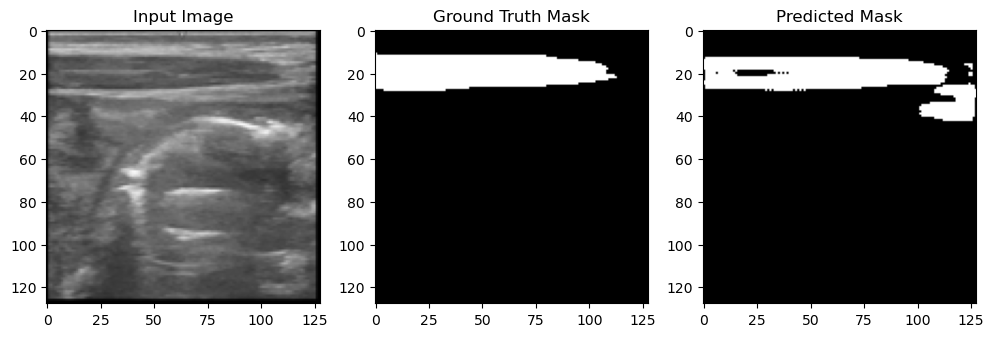

In [9]:
model.eval()  # Set model to evaluation mode
total_dice = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)
        
        outputs = model(images)
        preds = (outputs > 0.5).float()  # binarize predictions
        total_dice += dice_coefficient(preds, masks).item()

avg_dice = total_dice / len(val_loader)
print(f"Test Dice Score: {avg_dice:.4f}")

import random
rand_idx = random.randint(0, len(val_dataset)-1)
img, mask = val_dataset[rand_idx]
img_input = img.unsqueeze(0).to(device)
pred = model(img_input).cpu().detach().numpy()[0,0]
pred_bin = (pred > 0.5).astype(np.uint8) * 255

# Display prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img.permute(1,2,0).cpu())
plt.title("Input Image")
plt.subplot(1,3,2)
plt.imshow(mask[0].cpu(), cmap='gray')
plt.title("Ground Truth Mask")
plt.subplot(1,3,3)
plt.imshow(pred_bin, cmap='gray')
plt.title("Predicted Mask")
plt.show()

In [ ]:
print(f"Number of training images: {len(train_files)}")
print(f"Number of testing images: {len(val_files)}")

Number of training images: 181
Number of testing images: 46
